<a href="https://colab.research.google.com/github/mvharsh/Mathematical-Computing/blob/main/Determining_Critical_Path_Using_CPM_and_PERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DETERMINING THE CRITICAL PATH USING CPM AND PERT**

**AIM:**

To implement Critical Path Method (CPM) and Program Evaluation and Review Technique (PERT) for project scheduling, enabling efficient time estimation, identification of critical tasks, and probability analysis for project completion within a target duration.



**ALGORITHM:**


1.  **Compute Expected Duration & Standard Deviation**

	- Expected Duration:
TE = (O+4M+P)/6

	- Standard Deviation:
SD = (P−O)/6

2.  **Compute CPM (Critical Path Method)**

	- Create a directed graph and store activity durations.
	- Forward Pass: Compute Earliest Start (ES) and Earliest Finish (EF).
	- Backward Pass: Compute Latest Start (LS) and Latest Finish (LF).
	- Identify Critical Path (tasks with Slack = 0).

3.  **Compute PERT (Program Evaluation and Review Technique)**
	- Compute Total Variance and Standard Deviation:
σ =  √ ( ( ∑ SD)^2 )
	- Compute probability of completion within target days using normal distribution.

4.  **Visualization**
	- Draw project network graph, highlighting the Critical Path.

5.  **Input & Output Handling**
	- Take user input for activities and dependencies.
	- Display CPM & PERT results, including Critical Path, Slack, Project Duration, and Completion Probability.


Enter the number of activities: 7
Enter task name for activity 1: A
Enter optimistic time for A: 3
Enter most likely time for A: 6
Enter pessimistic time for A: 9
Enter predecessors for A (comma-separated, leave blank if none): 
Enter task name for activity 2: B
Enter optimistic time for B: 2
Enter most likely time for B: 5
Enter pessimistic time for B: 8
Enter predecessors for B (comma-separated, leave blank if none): 
Enter task name for activity 3: C
Enter optimistic time for C: 2
Enter most likely time for C: 4
Enter pessimistic time for C: 6
Enter predecessors for C (comma-separated, leave blank if none): A
Enter task name for activity 4: D
Enter optimistic time for D: 2
Enter most likely time for D: 3
Enter pessimistic time for D: 10
Enter predecessors for D (comma-separated, leave blank if none): B
Enter task name for activity 5: E
Enter optimistic time for E: 1
Enter most likely time for E: 3
Enter pessimistic time for E: 11
Enter predecessors for E (comma-separated, leave blan

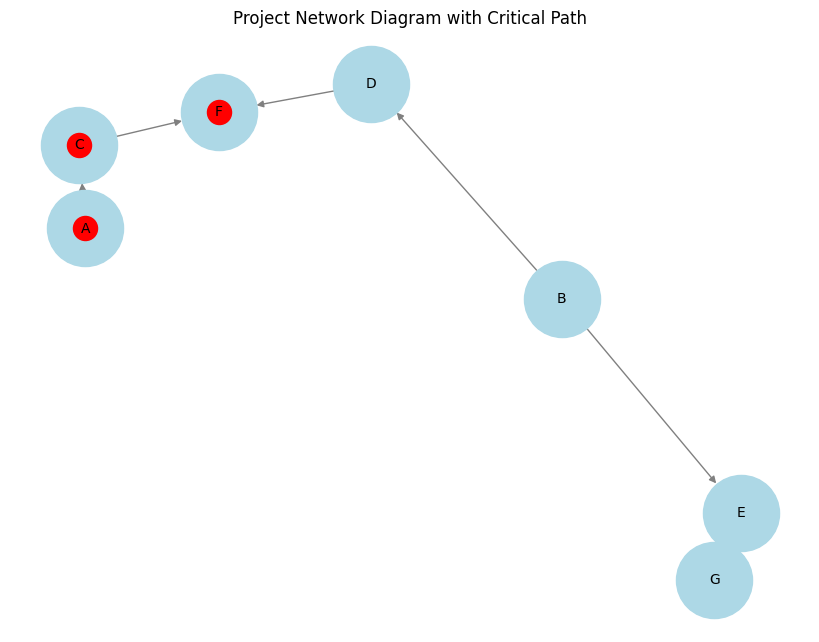

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def expected_duration(optimistic, most_likely, pessimistic):
    return round((optimistic + 4 * most_likely + pessimistic) / 6, 5)

def standard_deviation(optimistic, pessimistic):
    return round((pessimistic - optimistic) / 6, 5)

def compute_cpm(activities):
    G = nx.DiGraph()
    durations = {}
    std_devs = {}
    for activity in activities:
        task, optimistic, most_likely, pessimistic, predecessors = activity
        duration = expected_duration(optimistic, most_likely, pessimistic)
        std_dev = standard_deviation(optimistic, pessimistic)
        durations[task] = duration
        std_devs[task] = std_dev
        G.add_node(task, duration=duration)
        for pred in predecessors:
            G.add_edge(pred, task)

    earliest_start, earliest_finish = {}, {}
    for node in nx.topological_sort(G):
        earliest_start[node] = max([earliest_finish.get(pred, 0) for pred in G.predecessors(node)], default=0)
        earliest_finish[node] = earliest_start[node] + durations[node]

    project_duration = max(earliest_finish.values())
    latest_finish = {node: project_duration for node in G.nodes()}
    latest_start = {}
    for node in reversed(list(nx.topological_sort(G))):
        latest_start[node] = latest_finish[node] - durations[node]
        for pred in G.predecessors(node):
            latest_finish[pred] = min(latest_finish.get(pred, project_duration), latest_start[node])

    slack = {node: latest_start[node] - earliest_start[node] for node in G.nodes()}
    critical_path = [node for node in G.nodes() if slack[node] == 0]
    critical_path_str = " -> ".join(critical_path)

    return G, critical_path, project_duration, slack, earliest_start, earliest_finish, latest_start, latest_finish, std_devs, durations

def compute_pert(activities, project_duration, target_days, durations):
    variance = sum((standard_deviation(o, p) ** 2) for _, o, _, p, _ in activities)
    std_dev = round(np.sqrt(variance), 5)
    probability = round(norm.cdf(target_days, loc=project_duration, scale=std_dev) * 100, 2)
    return std_dev, probability, durations

def draw_project_network(G, critical_path):
    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, nodelist=critical_path, node_color='red')
    plt.title("Project Network Diagram with Critical Path")
    plt.show()

# Read user input
activities = []
n = int(input("Enter the number of activities: "))
for i in range(n):
    task = input(f"Enter task name for activity {i+1}: ")
    optimistic = float(input(f"Enter optimistic time for {task}: "))
    most_likely = float(input(f"Enter most likely time for {task}: "))
    pessimistic = float(input(f"Enter pessimistic time for {task}: "))
    predecessors = input(f"Enter predecessors for {task} (comma-separated, leave blank if none): ").split(',')
    predecessors = [p.strip() for p in predecessors if p.strip()]
    activities.append((task, optimistic, most_likely, pessimistic, predecessors))

G, critical_path, cpm_project_duration, slack, es, ef, ls, lf, std_devs, durations = compute_cpm(activities)
target_days = int(input("Enter target days: "))
project_std_dev, probability, pert_durations = compute_pert(activities, cpm_project_duration, target_days, durations)

print("\nCPM Results:")
print("Critical Path:", " -> ".join(critical_path))
print("Project Duration (CPM):", cpm_project_duration)
print("Early Start:", es)
print("Early Finish:", ef)
print("Late Start:", ls)
print("Late Finish:", lf)
print("Activity Slack:", slack)

print("\nPERT Results:")
print("Expected Project Duration:", cpm_project_duration)
print("Project Standard Deviation (PERT):", project_std_dev)
print("Activity Durations:", pert_durations)
print(f"Probability of Completion within {target_days} days: {probability}%")

draw_project_network(G, critical_path)